In [1]:
import yfinance as yf

# Get and save the historical data for the following tickers
tickers = [
    "ADBE",
    "AMD",
    "AXP",
    "XOM",
    "FDX",
    "HSY",
    "JPM",
    "HPE",
    "MRNA",
    "NVDA"
]

for each in tickers:
    
    # get ticker object
    tickr = yf.Ticker(each)
    
    # get historical data from 2015 - 2025
    data = tickr.history(start='2015-01-01', end='2025-01-01')

    data.to_csv(f"../data/raw/{each}.csv")

    print(f"Saved {each} data to ../data/raw/{each}.csv")


Saved ADBE data to ../data/raw/ADBE.csv
Saved AMD data to ../data/raw/AMD.csv
Saved AXP data to ../data/raw/AXP.csv
Saved XOM data to ../data/raw/XOM.csv
Saved FDX data to ../data/raw/FDX.csv
Saved HSY data to ../data/raw/HSY.csv
Saved JPM data to ../data/raw/JPM.csv
Saved HPE data to ../data/raw/HPE.csv
Saved MRNA data to ../data/raw/MRNA.csv
Saved NVDA data to ../data/raw/NVDA.csv


In [2]:
import pandas as pd

# Load each ticker data as its own dataframe

data = {}

for each in tickers:

    data[each] = pd.read_csv(f"../data/raw/{each}.csv")

data["NVDA"].head()


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2015-01-02 00:00:00-05:00,0.482423,0.486018,0.474754,0.482423,113680000,0.0,0.0
1,2015-01-05 00:00:00-05:00,0.482423,0.483861,0.472118,0.474275,197952000,0.0,0.0
2,2015-01-06 00:00:00-05:00,0.474994,0.475473,0.459416,0.459895,197764000,0.0,0.0
3,2015-01-07 00:00:00-05:00,0.463251,0.467325,0.457259,0.458697,321808000,0.0,0.0
4,2015-01-08 00:00:00-05:00,0.463970,0.478828,0.463730,0.475953,283780000,0.0,0.0


In [3]:
import matplotlib.pyplot as plt

# Plot ADBE, MRNA and NVDA close for full series
plot_tickers = ["ADBE","MRNA","NVDA"]

fig, axs = plt.subplots(figsize=(12,8), nrows=3, ncols=1, sharex=True)

for idx, ax in enumerate(axs):
    df = data[plot_tickers[idx]]
    ax.plot(df.Date, df.Close, label=plot_tickers[idx])
    ax.set_title(plot_tickers[idx])

    ticks = df.index[[0, len(df)//2, -1]]
    ax.set_xticks(ticks)

fig.supxlabel('Date')
fig.supylabel('Close')

fig.tight_layout()
#plt.show()
plt.close()

In [4]:
# FEATURES
import numpy as np

for each in tickers:


    df = data[each]
    df["Ticker"] = each

    # momentum
    df["momentum_1m"] = df.Close / df.Close.shift(30) - 1
    df["momentum_3m"] = df.Close / df.Close.shift(90) - 1
    df["momentum_6m"] = df.Close / df.Close.shift(180) - 1
    df["momentum_12m"] = df.Close / df.Close.shift(360) - 1

    # compute the log returns and then volatility
    df["log_ret"] = np.log(df.Close / df.Close.shift(1))
    df["volatility"] = df["log_ret"].rolling(window=252).std() * np.sqrt(252)   # from formula sqrt(252) 

    # get rolling volume change
    df["volume_ratio"] = df.Volume / df.Volume.rolling(30).mean()

    # get fwd return 30 day
    df["target"] = df.Close.shift(-30) / df.Close - 1

In [5]:
features = ["momentum_1m", "momentum_3m", "momentum_6m", "momentum_12m", "volatility", "volume_ratio"]

df_all = pd.concat(
    [df.assign(Ticker=ticker) for ticker, df in data.items()], ignore_index=True
)
df_all = df_all.dropna(subset=features + ["target"])

In [6]:
train = df_all[df_all.Date < "2022-01-01"]
valid = df_all[(df_all.Date >= "2022-01-01") & (df_all.Date < "2023-01-01")]
test = df_all[df_all.Date >= "2023-01-01"]

print(train.Date.min(), train.Date.max())
print(valid.Date.min(), valid.Date.max())
print(test.Date.min(), test.Date.max())

2016-06-08 00:00:00-04:00 2021-12-31 00:00:00-05:00
2022-01-03 00:00:00-05:00 2022-12-30 00:00:00-05:00
2023-01-03 00:00:00-05:00 2024-11-15 00:00:00-05:00


In [7]:
X_train = train[features]
Y_train = train["target"]

X_valid = valid[features]
Y_valid = valid["target"]

X_test = test[features]
Y_test = test["target"]

# use scalar on X
from sklearn.preprocessing import StandardScaler
scalar = StandardScaler()
X_train_scaled = scalar.fit_transform(X_train)
X_valid_scaled = scalar.fit_transform(X_valid)
X_test_scaled = scalar.fit_transform(X_test)

# now fit model to training set
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=1000)
ridge.fit(X_train_scaled, Y_train)
print("Model trained successfully, predicting from validation set...")
y_pred_ridge = ridge.predict(X_valid_scaled)

from sklearn.metrics import mean_squared_error
rmse_ridge = mean_squared_error(Y_valid, y_pred_ridge) ** 0.5
print(rmse_ridge)


Model trained successfully, predicting from validation set...
0.15449208228953903


In [8]:
baseline_pred = Y_train.mean()
rmse_baseline = mean_squared_error(Y_valid, [baseline_pred] * len(Y_valid)) ** 0.5
print(rmse_baseline)

0.15127820635183561


In [9]:
from sklearn.ensemble import GradientBoostingRegressor

gbreg = GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, max_depth=3)
gbreg.fit(X_train, Y_train)
y_pred_gb = gbreg.predict(X_valid)
rmse_gb = mean_squared_error(Y_valid, y_pred_gb) ** 0.5
print(rmse_gb)

0.15081811907220216


Mean IC:  -0.06582248699831017
Median IC: -0.09281101495443314
Std IC: 0.4798847499093701
Positive IC days: 0.4541832669322709


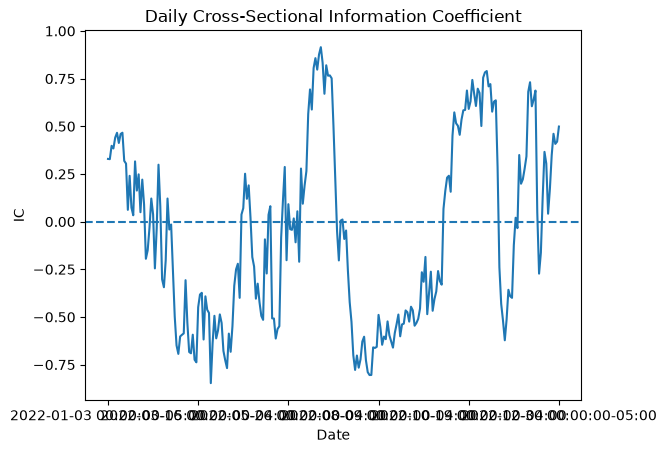

In [10]:
# Seperate out results from validation set
results = valid[["Date", "Ticker"]].copy()
results["predicted"] = y_pred_gb
results["actual"] = Y_valid

grouped = results.groupby("Date")
ic = grouped.apply(lambda x: x["predicted"].corr(x["actual"]))
print("Mean IC: ", ic.mean())
print("Median IC:", ic.median())
print("Std IC:", ic.std())
print("Positive IC days:", (ic > 0).mean())

ic.plot()
plt.axhline(0, linestyle="--")
plt.xlabel("Date")
plt.ylabel("IC")
plt.title("Daily Cross-Sectional Information Coefficient")
plt.show()

In [11]:
# INVESTIGATING SENSITIVITY TO PARAMETERS FOR GRADIENT BOOSTING
#from sklearn.pipeline import Pipeline

models = {
    "baseline": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3),
    "shallower": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=1),
    "more_trees": GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=3),
    "slower_learning": GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, max_depth=3)
}

for name, model in models.items():
    model.fit(X_train, Y_train)
    y_pred = model.predict(X_valid)
    rmse = mean_squared_error(Y_valid, y_pred) ** 0.5
    print(name,": RMSE = ", rmse)



baseline : RMSE =  0.15783400796419242
shallower : RMSE =  0.15471688765718478
more_trees : RMSE =  0.162870607328757
slower_learning : RMSE =  0.1508181190722022


In [12]:
lr_models = {
    "0.1": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3),
    "0.05": GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, max_depth=3),
    "0.005": GradientBoostingRegressor(n_estimators=100, learning_rate=0.005, max_depth=3),
    "0.0001": GradientBoostingRegressor(n_estimators=100, learning_rate=0.0001, max_depth=3)
}
print('Learning Rate |')
for name, model in lr_models.items():
    model.fit(X_train, Y_train)
    y_pred = model.predict(X_valid)
    rmse = mean_squared_error(Y_valid, y_pred) ** 0.5
    print(name,": RMSE = ", rmse)

Learning Rate |
0.1 : RMSE =  0.1576866055780654
0.05 : RMSE =  0.1508181190722022
0.005 : RMSE =  0.15167955604952035
0.0001 : RMSE =  0.1512693462376559


In [13]:
depth_models = {
    "1": GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, max_depth=1),
    "2": GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, max_depth=2),
    "3": GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, max_depth=3),
    "5": GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, max_depth=4)
}
print('Tree Depth |')
for name, model in depth_models.items():
    model.fit(X_train, Y_train)
    y_pred = model.predict(X_valid)
    rmse = mean_squared_error(Y_valid, y_pred) ** 0.5
    print(name,": RMSE = ", rmse)

Tree Depth |
1 : RMSE =  0.15390270377477674
2 : RMSE =  0.152344698807925
3 : RMSE =  0.1508181190722022
5 : RMSE =  0.15494927000843844


In [14]:
nest_models = {
    "50": GradientBoostingRegressor(n_estimators=50, learning_rate=0.05, max_depth=3),
    "100": GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, max_depth=3),
    "200": GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=3),
    "300": GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=3)
    }

print('N_estimators |')
for name, model in nest_models.items():
    model.fit(X_train, Y_train)
    y_pred = model.predict(X_valid)
    rmse = mean_squared_error(Y_valid, y_pred) ** 0.5
    print(name,": RMSE = ", rmse)

N_estimators |
50 : RMSE =  0.15150804694586326
100 : RMSE =  0.1508181190722022
200 : RMSE =  0.15463583981695245
300 : RMSE =  0.1578257958609437


Mean IC:  -0.06582248699831017
Median IC: -0.09281101495443314
Std IC: 0.4798847499093701
Positive IC days: 0.4541832669322709


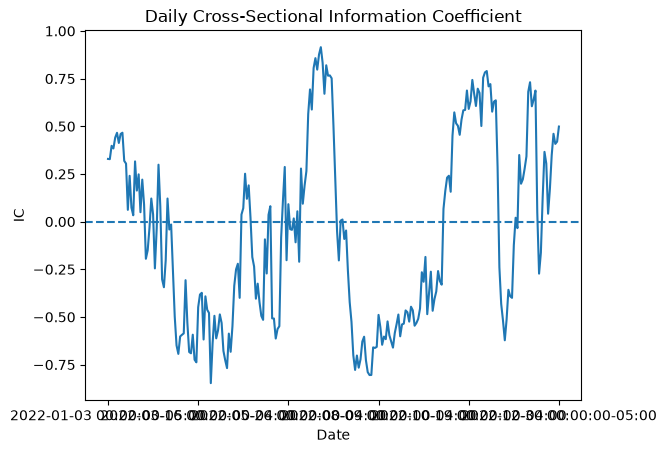

In [17]:
# NOW GETTING IC FOR GB MODEL FOR n_est = 100, learning_rate = 0.05, max_depth = 3
gbmodel = GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, max_depth=3)
gbmodel.fit(X_train, Y_train)
y_predicted = gbmodel.predict(X_valid)

results_gb = valid[["Date", "Ticker"]].copy()
results_gb["predicted"] = y_predicted
results_gb["actual"] = Y_valid

grouped_gb = results.groupby("Date")
ic_gb = grouped_gb.apply(lambda x: x["predicted"].corr(x["actual"]))
print("Mean IC: ", ic_gb.mean())
print("Median IC:", ic_gb.median())
print("Std IC:", ic_gb.std())
print("Positive IC days:", (ic_gb > 0).mean())

ic.plot()
plt.axhline(0, linestyle="--")
plt.xlabel("Date")
plt.ylabel("IC")
plt.title("Daily Cross-Sectional Information Coefficient")
plt.show()